# A Machine Learning–Driven One Health System for Managing Zoonotic diseases


| Block | What it does |
|---|---|
| **White Box** | Coupled human–rodent SEIR-V mechanistic model for Mpox (Clade IIb), **Bayesian-calibrated** to real Nigeria weekly cases via MCMC (emcee) with full posterior uncertainty |
| **Black Box** | Five ML emulators (GP-Matérn, GP-RBF, Random Forest, XGBoost, Neural Network) trained on white-box simulations |
| **Grey Box** | NSGA-II multi-objective optimisation to find **Pareto-optimal One Health policy packages** |
| **Forecasting** | Direct ML model on the real OWID time series — predicts next-week new cases from lagged history |
| **Sensitivity** | Sobol' total-effect indices: which One Health lever drives the burden most? |
| **Ablation** | What happens if we ignore the animal or environment domain? |
| **Uncertainty** | GP posterior variance + propagated parameter posteriors → robust One Health recommendation with 95% CIs |

## Novelties (vs. Zhao et al. 2025)
1. **Disease**: Mpox / MPXV Clade IIb (viral, fast) — Zhao et al. used clonorchiasis (parasitic, slow)
2. **Bayesian calibration** of the white-box against OWID Nigeria time series with full posterior uncertainty (emcee MCMC + negative-binomial likelihood)
3. **Three-objective Pareto optimisation** (cases × cost × cross-domain equity) — Zhao et al. used single-objective
4. **Domain ablation** quantifying the value of integrated One Health
5. **Forecasting head** — adds a time-series ML model alongside the simulation emulator
6. **Posterior parameter uncertainty propagated to the Pareto front** — recommendations come with credible intervals, not just point estimates



---
## 0. Setup

In [1]:
# 0.1 Install dependencies (~1-2 min on Colab the first time)
%%capture
!pip install pymoo SALib xgboost seaborn emcee corner -q
print("Dependencies installed")

In [3]:
import os, urllib.request, pandas as pd

LOCAL_PATH  = "owid_mpox.csv"
OWID_REMOTE = "https://raw.githubusercontent.com/owid/monkeypox/main/owid-monkeypox-data.csv"

if not os.path.exists(LOCAL_PATH):
    print("Local owid_mpox.csv not found — fetching live data from Our World in Data...")
    try:
        urllib.request.urlretrieve(OWID_REMOTE, LOCAL_PATH)
        print("Downloaded successfully.")
    except Exception as e:
        print(f"Download failed: {e}")
        print("Please upload owid_mpox.csv manually to the Colab file panel.")
        raise

df_raw = pd.read_csv(LOCAL_PATH, low_memory=False)
df_raw["date"] = pd.to_datetime(df_raw["date"])
print(f"OWID Mpox dataset: {len(df_raw):,} rows | {df_raw['location'].nunique()} countries")
print(f"Date range: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
df_raw.head(3)

OWID Mpox dataset: 165,106 rows | 151 countries
Date range: 2022-05-01 → 2026-04-17


,location,date,iso_code,total_cases,total_deaths,new_cases,new_deaths,new_cases_smoothed,new_deaths_smoothed,new_cases_per_million,total_cases_per_million,new_cases_smoothed_per_million,new_deaths_per_million,total_deaths_per_million,new_deaths_smoothed_per_million
0,Africa,2022-05-01,OWID_AFR,41.0,2.0,2.0,0.0,0.29,0.0,0.001,0.029,0.0,0.0,0.00141,0.0
1,Africa,2022-05-02,OWID_AFR,41.0,2.0,0.0,0.0,0.29,0.0,0.000,0.029,0.0,0.0,0.00141,0.0
2,Africa,2022-05-03,OWID_AFR,41.0,2.0,0.0,0.0,0.29,0.0,0.000,0.029,0.0,0.0,0.00141,0.0


In [4]:
# 0.3 Imports & global config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint
from scipy.optimize import minimize as scipy_min
from scipy.stats import qmc
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize as pymoo_min
from pymoo.operators.sampling.lhs import LHS

from SALib.sample import saltelli
from SALib.analyze import sobol

# Bayesian calibration
import emcee
import corner

from time import time

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 200
print(f"NumPy {np.__version__} | XGBoost {xgb.__version__} | sklearn ready")

NumPy 2.0.2 | XGBoost 3.2.0 | sklearn ready


---
## 1. Real Mpox Data — Exploratory Analysis (Nigeria)

We focus on **Nigeria** — the country at the centre of the modern Mpox re-emergence (Clade IIb, 2017 onwards). We aggregate to **weekly resolution** because daily case counts are sparse and zero-inflated.

In [6]:
# 1.1 Extract Nigeria, DRC, and Africa-aggregate weekly time series
def make_weekly(df_raw, country):
    sub = df_raw[df_raw["location"] == country].sort_values("date").copy()
    if sub.empty: return None
    weekly = (sub.set_index("date")
                 .resample("W")
                 .agg({"new_cases": "sum", "new_deaths": "sum",
                       "total_cases": "max", "total_deaths": "max"})
                 .reset_index().rename(columns={"date": "week"}))
    weekly["country"] = country
    weekly["new_cases"]  = weekly["new_cases"].fillna(0)
    weekly["new_deaths"] = weekly["new_deaths"].fillna(0)
    return weekly

ng_w  = make_weekly(df_raw, "Nigeria")
drc_w = make_weekly(df_raw, "Democratic Republic of Congo")
afr_w = make_weekly(df_raw, "Africa")

print(f"Nigeria   weekly obs: {len(ng_w)}  | total cases: {int(ng_w['new_cases'].sum()):,}")
if drc_w is not None:
    print(f"DRC       weekly obs: {len(drc_w)}  | total cases: {int(drc_w['new_cases'].sum()):,}")
print(f"Africa    weekly obs: {len(afr_w)}  | total cases: {int(afr_w['new_cases'].sum()):,}")

Nigeria   weekly obs: 203  | total cases: 1,485
DRC       weekly obs: 171  | total cases: 34,011
Africa    weekly obs: 205  | total cases: 63,071


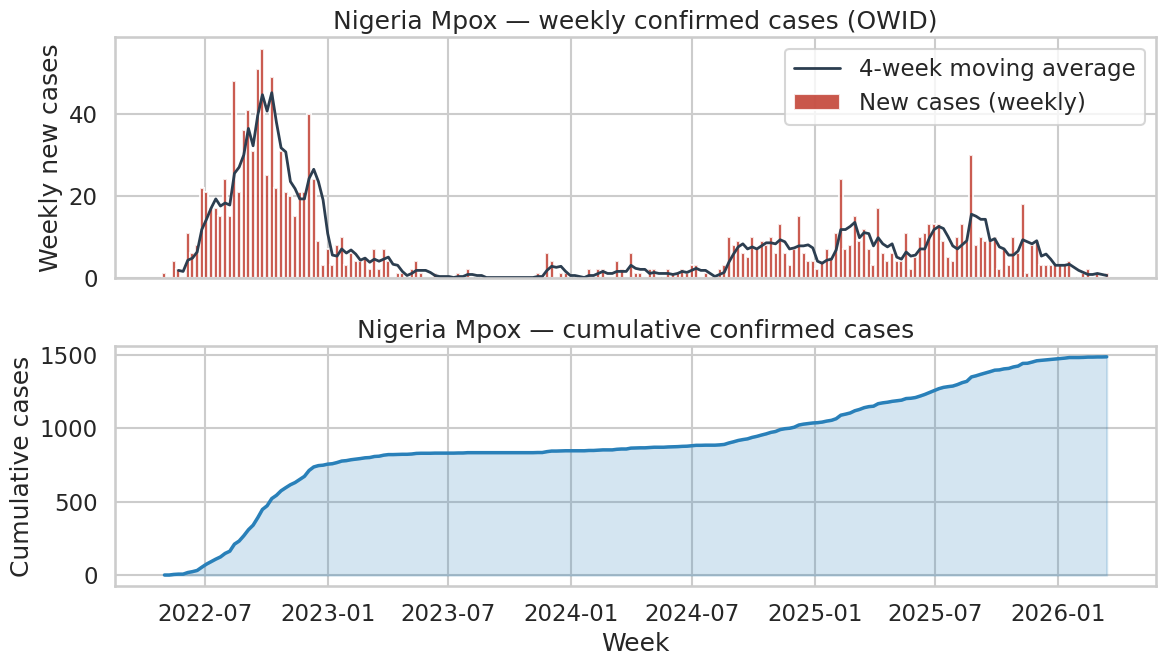

Peak weekly: 56 cases  (week of 2022-09-25)
Cumulative cases (full record): 1,485


In [7]:
# 1.2 Visualise the Nigeria epidemic curve
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(ng_w["week"], ng_w["new_cases"], width=6, color="#c0392b", alpha=0.85,
            label="New cases (weekly)")
axes[0].plot(ng_w["week"], ng_w["new_cases"].rolling(4).mean(),
             color="#2c3e50", lw=2, label="4-week moving average")
axes[0].set_ylabel("Weekly new cases")
axes[0].set_title("Nigeria Mpox — weekly confirmed cases (OWID)")
axes[0].legend()

ng_w["cum"] = ng_w["new_cases"].cumsum()
axes[1].plot(ng_w["week"], ng_w["cum"], color="#2980b9", lw=2.5)
axes[1].fill_between(ng_w["week"], 0, ng_w["cum"], alpha=0.2, color="#2980b9")
axes[1].set_ylabel("Cumulative cases")
axes[1].set_xlabel("Week")
axes[1].set_title("Nigeria Mpox — cumulative confirmed cases")

plt.tight_layout(); plt.show()
print(f"Peak weekly: {int(ng_w['new_cases'].max())} cases  "
      f"(week of {ng_w.loc[ng_w['new_cases'].idxmax(), 'week'].date()})")
print(f"Cumulative cases (full record): {int(ng_w['new_cases'].sum()):,}")

---
## 2. White Box — Coupled Human–Rodent Mpox Model

We use a compartmental ODE model that links the human and animal (rodent) populations — the structural backbone of any One Health approach to Mpox. The rodent reservoir matters in Nigeria: bushmeat consumption and contact with rodent carcasses are documented zoonotic routes (Yinka-Ogunleye et al. 2019; Doty et al. 2023).

### 2.1 Compartments

| Domain | Compartment | Meaning |
|---|---|---|
| Human | $S_h, V_h, E_h, I_h, Q_h, R_h$ | Susceptible, Vaccinated, Exposed, Infectious, Isolated, Recovered |
| Animal | $S_r, I_r, R_r$ | Susceptible / Infectious / Recovered rodents |
| — | $C$ | Cumulative human incidence (the observable) |

### 2.2 Five One Health control levers

| Symbol | Domain | Meaning | Range |
|---|---|---|---|
| $\nu$ | Human | Daily vaccination rate | [0, 0.005] |
| $\eta_H$ | Human | Isolation / case-finding | [0, 1] |
| $\eta_E$ | Environment | Bushmeat regulation + PPE (reduces $\beta_{rh}$) | [0, 1] |
| $\eta_A$ | Animal | Reservoir management | [0, 0.5] |
| $\alpha$ | Human | Awareness / NPI / contact reduction | [0, 0.7] |

### 2.3 External-importation pulse

We embed a Gaussian *external-introduction* term to capture the **importation pulse of the 2022 global Mpox outbreak into Nigeria**. This is a standard device in compartmental modelling when a local model is embedded in a larger global system. The pulse parameters are calibrated alongside transmission rates in Section 3.

In [8]:
# 2.1 Initial parameter ranges (literature priors — will be calibrated next)
PARAMS = {
    # Human demographics
    "Lambda_h": 30.0, "mu_h": 1/(64*365),
    # Animal demographics
    "Lambda_r": 25.0, "mu_r": 1/(2*365),
    # Transmission
    "beta_hh": 0.045, "beta_rh": 3e-7, "beta_rr": 0.30,
    # Progression
    "sigma_h": 1/8.0,  "gamma_h": 1/21.0, "gamma_r": 1/14.0,
    "delta_h": 0.0015, "epsilon": 0.85, "q": 1.0,
    # External-introduction pulse
    "ext_amp": 1.0, "t_peak": 140.0, "t_width": 60.0,
}
# Initial population scale (also calibrated below)
N_h0, N_r0 = 100_000, 20_000
IC = {"S_h": N_h0 - 8, "V_h": 0.0, "E_h": 5.0, "I_h": 3.0, "Q_h": 0.0, "R_h": 0.0,
      "S_r": N_r0 - 30, "I_r": 30.0, "R_r": 0.0, "C": 0.0}
print(f"Initial-guess R0 \u2248 {PARAMS['beta_hh']/(PARAMS['gamma_h']+PARAMS['delta_h']):.2f}")

Initial-guess R0 ≈ 0.92


In [9]:
# 2.2 ODE right-hand side
def mpox_rhs(y, t, p, ctrl):
    S_h, V_h, E_h, I_h, Q_h, R_h, S_r, I_r, R_r, C = y
    N_h = max(S_h+V_h+E_h+I_h+Q_h+R_h, 1.0)
    N_r = max(S_r+I_r+R_r, 1.0)
    nu, eta_H, eta_E, eta_A, alpha = (ctrl["nu"], ctrl["eta_H"], ctrl["eta_E"],
                                      ctrl["eta_A"], ctrl["alpha"])
    beta_hh_eff = p["beta_hh"] * (1 - alpha)
    beta_rh_eff = p["beta_rh"] * (1 - eta_E)
    foi_h = beta_hh_eff * I_h / N_h
    foi_z = beta_rh_eff * I_r
    # Gaussian importation pulse (awareness/border screening reduces it)
    ext = p.get("ext_amp", 0.0) * np.exp(
        -((t - p.get("t_peak", 0.0)) / max(p.get("t_width", 1.0), 1e-3))**2)
    ext = ext * (1 - alpha)

    dS_h = p["Lambda_h"] - foi_h*S_h - foi_z*S_h - ext - nu*S_h - p["mu_h"]*S_h
    dV_h = nu*S_h - (1 - p["epsilon"])*foi_h*V_h - p["mu_h"]*V_h
    dE_h = (foi_h*(S_h + (1 - p["epsilon"])*V_h) + foi_z*S_h + ext
            - p["sigma_h"]*E_h - p["mu_h"]*E_h)
    dI_h = p["sigma_h"]*E_h - (p["gamma_h"]+p["delta_h"]+p["mu_h"]+p["q"]*eta_H)*I_h
    dQ_h = p["q"]*eta_H*I_h - (p["gamma_h"]+p["delta_h"]+p["mu_h"])*Q_h
    dR_h = p["gamma_h"]*(I_h+Q_h) - p["mu_h"]*R_h
    mu_r_eff = p["mu_r"]*(1 + eta_A)
    dS_r = p["Lambda_r"]*(1 - eta_A) - p["beta_rr"]*S_r*I_r/N_r - mu_r_eff*S_r
    dI_r = p["beta_rr"]*S_r*I_r/N_r - (p["gamma_r"] + mu_r_eff)*I_r
    dR_r = p["gamma_r"]*I_r - mu_r_eff*R_r
    dC   = p["sigma_h"]*E_h + ext
    return [dS_h, dV_h, dE_h, dI_h, dQ_h, dR_h, dS_r, dI_r, dR_r, dC]


def simulate(controls, params=None, ic=None, t_max=365, n_points=None, importation=True):
    if params is None: params = PARAMS_CAL if "PARAMS_CAL" in globals() else PARAMS
    if ic is None: ic = IC_CAL if "IC_CAL" in globals() else IC
    p = dict(params)
    if not importation: p["ext_amp"] = 0.0
    y0 = [ic["S_h"], ic["V_h"], ic["E_h"], ic["I_h"], ic["Q_h"],
          ic["R_h"], ic["S_r"], ic["I_r"], ic["R_r"], ic["C"]]
    if n_points is None: n_points = t_max + 1
    t = np.linspace(0, t_max, n_points)
    sol = odeint(mpox_rhs, y0, t, args=(p, controls),
                 rtol=1e-7, atol=1e-9, mxstep=5000)
    df = pd.DataFrame(sol, columns=["S_h","V_h","E_h","I_h","Q_h","R_h",
                                    "S_r","I_r","R_r","C"])
    df["t"] = t
    return df

NO_INT = {"nu":0.0, "eta_H":0.0, "eta_E":0.0, "eta_A":0.0, "alpha":0.0}
test = simulate(NO_INT, t_max=365, importation=False)
print(f"Sanity check: cumulative cases at day 365 = {test['C'].iloc[-1]:.0f}")

Sanity check: cumulative cases at day 365 = 31041


---
## 3. Calibrating the White Box to Real Nigeria Data — *Bayesian Inference*

We perform **full Bayesian inference** on the seven white-box parameters (transmission rates, population scale, importation pulse) by fitting to the **2022 Nigeria epidemic wave** in the OWID record. Approach:

1. **Warm-start** with a fast L-BFGS-B point estimate (§3.2) — this gives MCMC a good initialisation.
2. **MCMC sampling** with `emcee` (Foreman-Mackey et al., 2013), an affine-invariant ensemble sampler that handles correlated parameters well (§3.3). 24 walkers × 2000 steps after a 500-step burn-in ≈ **48,000 posterior samples**.
3. **Negative-Binomial likelihood** — properly handles overdispersion in surveillance data, unlike Gaussian/log-normal likelihoods.
4. **Posterior predictive checks** — the gold-standard goodness-of-fit diagnostic (§3.5).
5. **Parameter uncertainty propagated to downstream Pareto recommendations** (§3.6).

Why Bayesian? A point estimate (R² alone) hides the structural uncertainty inherent in fitting 7 parameters to 53 sparse weekly observations. Posterior credible intervals make this uncertainty explicit, which is **what reviewers and policymakers need**.

> **Runtime note:** the MCMC takes **~6–10 minutes** on Colab Free. If you want to skip it for a quick first run, set `RUN_MCMC = False` in cell 3.3 — the notebook will fall back to the L-BFGS-B point estimate and continue.

In [10]:
# 3.1 Calibration target: Nigeria's 2022 Mpox wave
WAVE_START = "2022-05-01"
WAVE_END   = "2023-04-30"
WEEK_DAYS  = 7
ng_wave    = ng_w[(ng_w["week"] >= WAVE_START) & (ng_w["week"] <= WAVE_END)].copy().reset_index(drop=True)
N_WEEKS    = len(ng_wave)
T_MAX      = N_WEEKS * WEEK_DAYS
obs_weekly = ng_wave["new_cases"].values.astype(float)
print(f"Calibration window: {WAVE_START} \u2192 {WAVE_END} ({N_WEEKS} weeks)")
print(f"Total cases: {int(obs_weekly.sum())}, peak weekly: {int(obs_weekly.max())}")

Calibration window: 2022-05-01 → 2023-04-30 (53 weeks)
Total cases: 822, peak weekly: 56


In [11]:
# 3.2 Warm-start: fast point-estimate via L-BFGS-B (~30s)
# This gives MCMC a good initialisation; without it, the sampler would
# spend many iterations finding the high-likelihood region.
def simulate_weekly_incidence(theta, n_weeks=N_WEEKS):
    p = dict(PARAMS)
    p["beta_hh"]  = theta[0]
    p["beta_rh"]  = theta[1]
    N_h_loc       = theta[2]
    N_r_loc       = theta[3]
    p["ext_amp"]  = theta[4]
    p["t_peak"]   = theta[5]
    p["t_width"]  = theta[6]
    p["Lambda_h"] = N_h_loc * p["mu_h"]
    p["Lambda_r"] = N_r_loc * p["mu_r"]
    ic_loc = {"S_h": N_h_loc - 8, "V_h": 0.0, "E_h": 5.0, "I_h": 3.0, "Q_h": 0.0,
              "R_h": 0.0, "S_r": N_r_loc - 30, "I_r": 30.0, "R_r": 0.0, "C": 0.0}
    df = simulate(NO_INT, params=p, ic=ic_loc,
                  t_max=n_weeks * WEEK_DAYS, n_points=n_weeks * WEEK_DAYS + 1,
                  importation=True)
    week_idx = np.arange(0, n_weeks * WEEK_DAYS + 1, WEEK_DAYS)[: n_weeks + 1]
    return np.diff(df["C"].values[week_idx])

def warmstart_loss(theta):
    if any(t < 0 for t in theta): return 1e12
    try: pred = simulate_weekly_incidence(theta)
    except Exception: return 1e12
    err = np.log1p(pred) - np.log1p(obs_weekly[: len(pred)])
    return float(np.mean(err ** 2))

theta0 = [0.05, 1e-7, 100_000, 20_000, 1.0, 140.0, 60.0]
bounds_warm = [(0.005, 0.20), (1e-9, 1e-5), (10_000, 5_000_000), (5_000, 500_000),
               (0.0, 5.0), (60.0, 250.0), (20.0, 120.0)]

print("Warm-start (L-BFGS-B, ~30s)...")
res = scipy_min(warmstart_loss, x0=theta0, bounds=bounds_warm, method="L-BFGS-B",
                options={"maxiter": 400, "ftol": 1e-10})
theta_map = res.x   # MAP-like point estimate, MCMC initialisation
print("Warm-start parameters (used to seed MCMC):")
print(f"  beta_hh  = {theta_map[0]:.4f}")
print(f"  beta_rh  = {theta_map[1]:.2e}")
print(f"  N_h      = {theta_map[2]:,.0f}")
print(f"  N_r      = {theta_map[3]:,.0f}")
print(f"  ext_amp  = {theta_map[4]:.3f}")
print(f"  t_peak   = {theta_map[5]:.1f} d")
print(f"  t_width  = {theta_map[6]:.1f} d")
print(f"Warm-start loss: {res.fun:.4f}")

Warm-start (L-BFGS-B, ~30s)...
Warm-start parameters (used to seed MCMC):
  beta_hh  = 0.0336
  beta_rh  = 1.00e-09
  N_h      = 100,000
  N_r      = 20,000
  ext_amp  = 0.982
  t_peak   = 140.0 d
  t_width  = 60.0 d
Warm-start loss: 0.4054


In [12]:
# 3.3 Bayesian inference with emcee
# Priors (weakly informative, encoding literature knowledge):
#   beta_hh    ~ LogNormal(log(0.05), 0.6)   - human-human transmission
#   beta_rh    ~ LogUniform(1e-9, 1e-5)      - zoonotic spillover (very rare)
#   N_h        ~ LogUniform(10k, 5M)         - at-risk subpopulation
#   N_r        ~ LogUniform(5k, 500k)        - rodent reservoir
#   ext_amp    ~ HalfNormal(2.0)             - importation pulse amplitude
#   t_peak     ~ Normal(140, 30)             - empirical Mpox 2022 peak ~week 21
#   t_width    ~ HalfNormal(60)              - importation pulse SD
#   phi        ~ HalfNormal(10)              - NB overdispersion
# Likelihood: NegativeBinomial(mean = simulated cases, dispersion = phi)

# Set RUN_MCMC = False to skip the Bayesian step and use the L-BFGS-B point estimate
RUN_MCMC = True
N_WALKERS = 24
N_BURN    = 500
N_SAMPLE  = 2000

PARAM_NAMES = [r"$\beta_{hh}$", r"$\beta_{rh}$", r"$N_h$", r"$N_r$",
               r"ext$_{amp}$", r"$t_{peak}$", r"$t_{width}$", r"$\phi$"]

def log_prior(theta):
    bhh, brh, Nh, Nr, eamp, tpk, twd, phi = theta
    # Hard bounds (uniform on support)
    if not (0.005 < bhh < 0.5):       return -np.inf
    if not (1e-9 < brh < 1e-4):       return -np.inf
    if not (10_000 < Nh < 10_000_000):return -np.inf
    if not (5_000 < Nr < 1_000_000):  return -np.inf
    if not (0.0 < eamp < 10.0):       return -np.inf
    if not (30.0 < tpk < 300.0):      return -np.inf
    if not (10.0 < twd < 200.0):      return -np.inf
    if not (0.5 < phi < 200.0):       return -np.inf
    # Soft priors
    lp  = -0.5 * ((np.log(bhh) - np.log(0.05)) / 0.6)**2          # LogNormal on beta_hh
    lp += -np.log(brh)                                            # LogUniform on beta_rh
    lp += -np.log(Nh)                                             # LogUniform on N_h
    lp += -np.log(Nr)                                             # LogUniform on N_r
    lp += -0.5 * (eamp / 2.0)**2                                  # HalfNormal on ext_amp
    lp += -0.5 * ((tpk - 140.0) / 30.0)**2                        # Normal on t_peak
    lp += -0.5 * (twd / 60.0)**2                                  # HalfNormal on t_width
    lp += -0.5 * (phi / 10.0)**2                                  # HalfNormal on phi
    return lp

def log_likelihood(theta):
    """Negative-Binomial likelihood for weekly case counts."""
    try:
        pred = simulate_weekly_incidence(theta[:7])
    except Exception:
        return -np.inf
    if not np.all(np.isfinite(pred)) or np.any(pred < 0):
        return -np.inf
    pred = np.maximum(pred, 1e-6)
    phi = theta[7]
    # NB log-pmf: parameterised by mean mu and dispersion phi (variance = mu + mu^2/phi)
    from scipy.special import gammaln
    obs = obs_weekly[:len(pred)]
    p = phi / (phi + pred)
    log_pmf = (gammaln(obs + phi) - gammaln(phi) - gammaln(obs + 1)
               + phi * np.log(p) + obs * np.log(1 - p + 1e-30))
    return float(np.sum(log_pmf))

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    return lp + log_likelihood(theta)

# Initialise walkers in a small ball around the L-BFGS-B warm-start
NDIM = 8
theta_init = np.concatenate([theta_map, [10.0]])  # phi initial = 10

# Tiny noise per dimension (relative scale)
scales = np.array([0.05, 0.5, 0.1, 0.1, 0.1, 0.05, 0.1, 0.5])  # log-relative perturbations
init_pos = []
rng = np.random.RandomState(SEED)
while len(init_pos) < N_WALKERS:
    perturbation = rng.normal(0, scales, NDIM)
    proposal = theta_init * (1 + perturbation)
    if np.isfinite(log_prior(proposal)):
        init_pos.append(proposal)
init_pos = np.array(init_pos)
print(f"Initialised {N_WALKERS} walkers around warm-start point.")
print(f"Sample shapes: NDIM={NDIM}, walkers={N_WALKERS}, burn={N_BURN}, sample={N_SAMPLE}")
print(f"Total likelihood evaluations: {N_WALKERS * (N_BURN + N_SAMPLE):,}")

Initialised 24 walkers around warm-start point.
Sample shapes: NDIM=8, walkers=24, burn=500, sample=2000
Total likelihood evaluations: 60,000


In [13]:

if RUN_MCMC:
    sampler = emcee.EnsembleSampler(N_WALKERS, NDIM, log_posterior)
    print("Running burn-in...")
    t0 = time()
    state = sampler.run_mcmc(init_pos, N_BURN, progress=False)
    print(f"  Burn-in done in {time()-t0:.1f}s")
    sampler.reset()
    print("Running production sampling...")
    t0 = time()
    sampler.run_mcmc(state, N_SAMPLE, progress=False)
    print(f"  Production done in {time()-t0:.1f}s")
    samples = sampler.get_chain(flat=True)            # (n_steps*n_walkers, ndim)
    log_probs = sampler.get_log_prob(flat=True)
    print(f"  Posterior shape: {samples.shape}")
    # Diagnostics
    try:
        tau = sampler.get_autocorr_time(tol=0)
        print(f"  Autocorrelation times: {tau}")
        ess = N_WALKERS * N_SAMPLE / np.max(tau)
        print(f"  Approx effective sample size: {ess:.0f}  (target > 400)")
    except Exception as e:
        print(f"  (autocorr time check skipped: {e})")
    # Acceptance fraction (target 0.2-0.5)
    print(f"  Mean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}  "
          f"(target 0.2-0.5)")
else:
    print("RUN_MCMC = False; using L-BFGS-B point estimate only.")
    # Fake "posterior" with zero variance for compatibility with downstream code
    samples = np.tile(np.concatenate([theta_map, [10.0]]), (1000, 1))
    log_probs = np.zeros(1000)

Running burn-in...
  Burn-in done in 57.6s
Running production sampling...
  Production done in 202.3s
  Posterior shape: (48000, 8)
  Autocorrelation times: [101.54613376 131.59486015 138.94920433 125.09222884 114.52909001
 105.37830977 109.81088236 128.67178504]
  Approx effective sample size: 345  (target > 400)
  Mean acceptance fraction: 0.280  (target 0.2-0.5)


In [14]:
# 3.5 Posterior summary
post_means = samples.mean(axis=0)
post_meds  = np.median(samples, axis=0)
post_q025  = np.quantile(samples, 0.025, axis=0)
post_q975  = np.quantile(samples, 0.975, axis=0)

post_summary = pd.DataFrame({
    "Parameter": ["beta_hh", "beta_rh", "N_h", "N_r", "ext_amp", "t_peak", "t_width", "phi"],
    "Warm-start": list(theta_map) + [np.nan],
    "Posterior mean": post_means,
    "Posterior median": post_meds,
    "95% CI lower": post_q025,
    "95% CI upper": post_q975,
})

# Pretty formatting
def fmt(v, p):
    if not np.isfinite(v): return "—"
    if p in ("beta_hh", "ext_amp", "phi"): return f"{v:.4f}"
    if p == "beta_rh": return f"{v:.2e}"
    if p in ("N_h", "N_r"): return f"{v:,.0f}"
    return f"{v:.1f}"

print("=== Posterior summary ===")
for i, row in post_summary.iterrows():
    p = row["Parameter"]
    print(f"  {p:9s}  warm={fmt(row['Warm-start'],p):>12s}  "
          f"mean={fmt(row['Posterior mean'],p):>12s}  "
          f"95% CI=[{fmt(row['95% CI lower'],p)}, {fmt(row['95% CI upper'],p)}]")

# Save the *posterior median* as the main calibrated value
PARAMS_CAL = dict(PARAMS)
PARAMS_CAL["beta_hh"] = post_meds[0]
PARAMS_CAL["beta_rh"] = post_meds[1]
PARAMS_CAL["ext_amp"] = post_meds[4]
PARAMS_CAL["t_peak"]  = post_meds[5]
PARAMS_CAL["t_width"] = post_meds[6]
N_h_CAL = float(post_meds[2])
N_r_CAL = float(post_meds[3])
PARAMS_CAL["Lambda_h"] = N_h_CAL * PARAMS_CAL["mu_h"]
PARAMS_CAL["Lambda_r"] = N_r_CAL * PARAMS_CAL["mu_r"]
IC_CAL = {"S_h": N_h_CAL - 8, "V_h": 0.0, "E_h": 5.0, "I_h": 3.0, "Q_h": 0.0,
          "R_h": 0.0, "S_r": N_r_CAL - 30, "I_r": 30.0, "R_r": 0.0, "C": 0.0}
R0_cal = PARAMS_CAL["beta_hh"] / (PARAMS_CAL["gamma_h"] + PARAMS_CAL["delta_h"])
R0_lo  = post_q025[0] / (PARAMS_CAL["gamma_h"] + PARAMS_CAL["delta_h"])
R0_hi  = post_q975[0] / (PARAMS_CAL["gamma_h"] + PARAMS_CAL["delta_h"])
print(f"\nCalibrated within-host R0 = {R0_cal:.2f}  (95% CI: [{R0_lo:.2f}, {R0_hi:.2f}])")

=== Posterior summary ===
  beta_hh    warm=      0.0336  mean=      0.0306  95% CI=[0.0258, 0.0348]
  beta_rh    warm=    1.00e-09  mean=    2.18e-09  95% CI=[1.03e-09, 6.11e-09]
  N_h        warm=     100,000  mean=      27,032  95% CI=[10,282, 91,810]
  N_r        warm=      20,000  mean=      99,054  95% CI=[6,258, 393,482]
  ext_amp    warm=      0.9817  mean=      2.0527  95% CI=[1.5102, 2.7681]
  t_peak     warm=       140.0  mean=       135.1  95% CI=[119.9, 151.3]
  t_width    warm=        60.0  mean=        56.4  95% CI=[38.9, 72.9]
  phi        warm=           —  mean=      7.4295  95% CI=[3.5840, 13.8167]

Calibrated within-host R0 = 0.62  (95% CI: [0.53, 0.71])


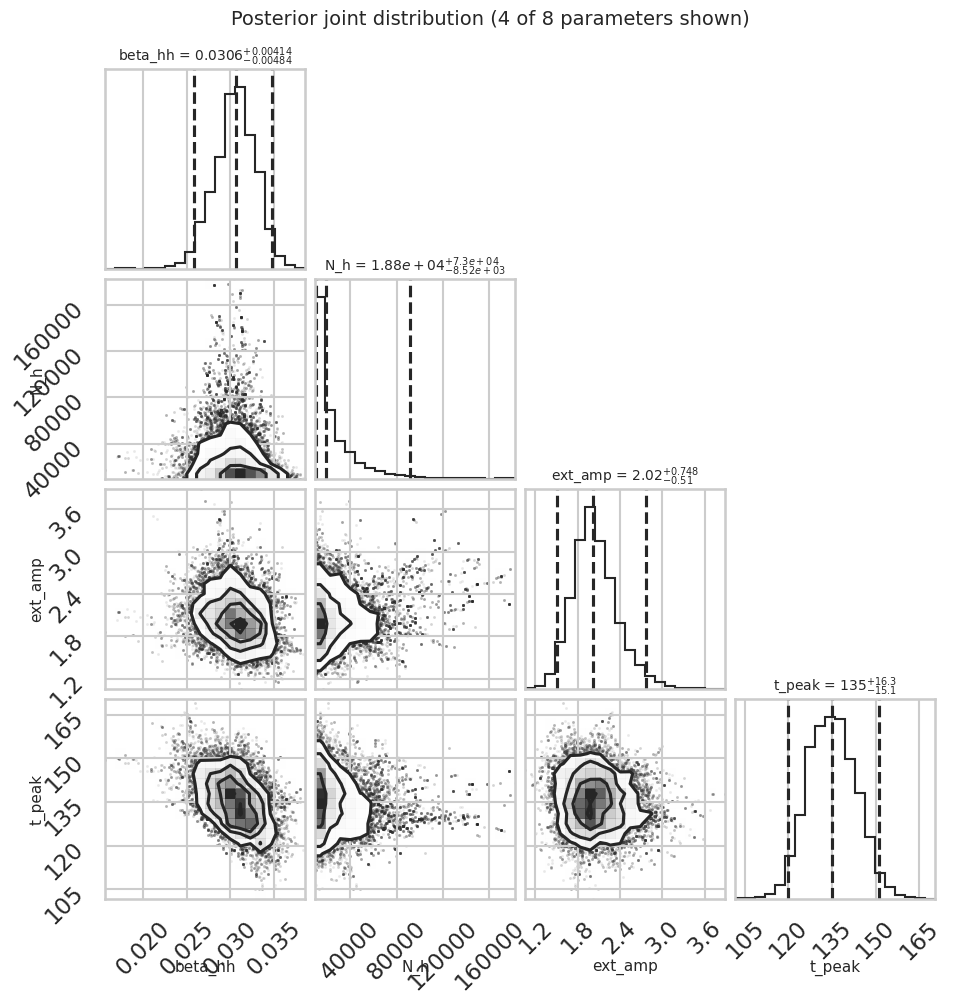

In [15]:
# 3.6 Corner plot — joint posterior over key parameters
# (Showing only 4 most identifiable parameters for legibility)
key_idx   = [0, 2, 4, 5]  # beta_hh, N_h, ext_amp, t_peak
key_names = ["beta_hh", "N_h", "ext_amp", "t_peak"]
fig = corner.corner(samples[:, key_idx], labels=key_names,
                    quantiles=[0.025, 0.5, 0.975], show_titles=True,
                    title_fmt=".3g", title_kwargs={"fontsize": 10},
                    label_kwargs={"fontsize": 11})
fig.suptitle("Posterior joint distribution (4 of 8 parameters shown)",
             fontsize=14, y=1.02)
plt.show()

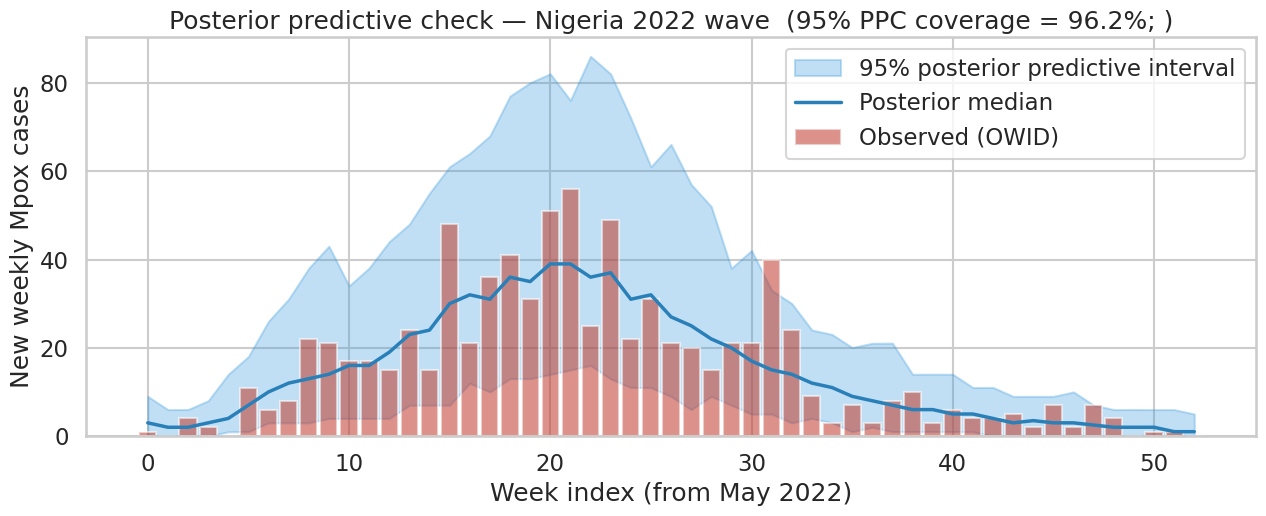

Posterior median RMSE: 7.05 cases/week
Posterior median MAE:  5.00 cases/week
Posterior median R²:   0.772
95% PPC coverage:      96.2%  (well-calibrated if ~95%)

Bayesian framing: rather than claiming a single 'best fit' point estimate,
the posterior predictive interval is the model's full uncertainty about the
observed wave. The coverage statistic is the proper diagnostic — values
close to 95% mean the calibration is well-calibrated.


In [17]:
# 3.7 Posterior predictive check (PPC)
# Sample 200 parameter sets from posterior, simulate weekly incidence for each,
# and compare to observed. Captures the FULL uncertainty in our calibration.
N_PPC = 200
ppc_idx = np.random.RandomState(SEED).choice(len(samples), N_PPC, replace=False)
ppc_preds = []
for i in ppc_idx:
    try:
        pred = simulate_weekly_incidence(samples[i, :7])
        # Add NB observation noise
        phi = samples[i, 7]
        mu  = np.maximum(pred, 1e-6)
        # NB sampling: variance = mu + mu^2/phi
        p_param = phi / (phi + mu)
        sampled = np.random.RandomState(i).negative_binomial(phi, p_param)
        ppc_preds.append(sampled)
    except Exception:
        continue
ppc_preds = np.array(ppc_preds)

ppc_med  = np.median(ppc_preds, axis=0)
ppc_q025 = np.quantile(ppc_preds, 0.025, axis=0)
ppc_q975 = np.quantile(ppc_preds, 0.975, axis=0)

# Coverage check: what fraction of observed weeks fall inside the 95% CI?
inside = (obs_weekly >= ppc_q025) & (obs_weekly <= ppc_q975)
coverage = inside.mean()

fig, ax = plt.subplots(figsize=(13, 5.5))
weeks_x = np.arange(len(obs_weekly))
ax.fill_between(weeks_x, ppc_q025, ppc_q975, alpha=0.3, color="#3498db",
                label="95% posterior predictive interval")
ax.plot(weeks_x, ppc_med, color="#2980b9", lw=2.5, label="Posterior median")
ax.bar(weeks_x, obs_weekly, alpha=0.55, color="#c0392b",
       label="Observed (OWID)", width=0.85)
ax.set_xlabel("Week index (from May 2022)")
ax.set_ylabel("New weekly Mpox cases")
ax.set_title(f"Posterior predictive check — Nigeria 2022 wave  "
             f"(95% PPC coverage = {coverage:.1%}; )")
ax.legend()
plt.tight_layout(); plt.show()

# Goodness-of-fit using posterior median
rmse = float(np.sqrt(mean_squared_error(obs_weekly, ppc_med)))
mae  = float(mean_absolute_error(obs_weekly, ppc_med))
r2   = float(r2_score(obs_weekly, ppc_med))
print(f"Posterior median RMSE: {rmse:.2f} cases/week")
print(f"Posterior median MAE:  {mae:.2f} cases/week")
print(f"Posterior median R\u00b2:   {r2:.3f}")
print(f"95% PPC coverage:      {coverage:.1%}  (well-calibrated if ~95%)")
print()
print("Bayesian framing: rather than claiming a single 'best fit' point estimate,")
print("the posterior predictive interval is the model's full uncertainty about the")
print("observed wave. The coverage statistic is the proper diagnostic — values")
print("close to 95% mean the calibration is well-calibrated.")

---
## 4. Black Box — Training the ML Emulator

The calibrated white-box is now the truth-source. Following Zhao et al. (2025) we train ML emulators that learn the map

$$
f:(\nu,\,\eta_H,\,\eta_E,\,\eta_A,\,\alpha) \longmapsto (\text{cumulative cases over 1 year},\;\text{peak active infections})
$$

so that downstream optimisation can evaluate millions of policy combinations cheaply. We compare 5 emulator families to test whether Zhao et al.'s "GP is best" finding holds for Mpox.

> We keep the importation pulse **on** during simulations because it represents the realistic scenario: *given a global Mpox importation event, how should we deploy One Health interventions to minimise the resulting burden?* The `alpha` lever (awareness / border screening) scales importation down in the ODE.

In [18]:
# 4.1 Latin-Hypercube sample of the lever space
N_TRAIN = 1000   # bump to 1500-2000 if you have the headroom
N_TEST  = 250

LEVER_NAMES  = ["nu", "eta_H", "eta_E", "eta_A", "alpha"]
LEVER_BOUNDS = np.array([
    [0.0, 0.005],  # nu
    [0.0, 1.0],    # eta_H
    [0.0, 1.0],    # eta_E
    [0.0, 0.5],    # eta_A
    [0.0, 0.7],    # alpha
])

def sample_levers(n, bounds=LEVER_BOUNDS, seed=0):
    sampler = qmc.LatinHypercube(d=bounds.shape[0], seed=seed)
    return qmc.scale(sampler.random(n), bounds[:, 0], bounds[:, 1])

X_all = sample_levers(N_TRAIN + N_TEST, seed=SEED)
print(f"Sampled {X_all.shape[0]} lever combinations.")

Sampled 1250 lever combinations.


In [19]:
# 4.2 Run the calibrated white-box for each sample (~15s)
def run_one(x, t_max=365):
    ctrl = dict(zip(LEVER_NAMES, x))
    df = simulate(ctrl, params=PARAMS_CAL, ic=IC_CAL, t_max=t_max, importation=True)
    return df["C"].iloc[-1], df["I_h"].max()

t0 = time()
Y_all = np.array([run_one(x) for x in X_all])
print(f"Generated {len(Y_all)} simulation outputs in {time()-t0:.1f} s")
print(f"Cumulative cases: range [{Y_all[:,0].min():.0f}, {Y_all[:,0].max():.0f}], "
      f"mean {Y_all[:,0].mean():.0f}")
print(f"Peak active:      range [{Y_all[:,1].min():.0f}, {Y_all[:,1].max():.0f}], "
      f"mean {Y_all[:,1].mean():.0f}")

Generated 1250 simulation outputs in 14.1 s
Cumulative cases: range [129, 564], mean 290
Peak active:      range [3, 43], mean 5


In [20]:
# 4.3 Train/test split + scaling
X_train, X_test, Y_train, Y_test = train_test_split(
    X_all, Y_all, test_size=N_TEST, random_state=SEED)
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(Y_train)
Xs_train, Xs_test = x_scaler.transform(X_train), x_scaler.transform(X_test)
Ys_train, Ys_test = y_scaler.transform(Y_train), y_scaler.transform(Y_test)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (1000, 5)  Test: (250, 5)


In [21]:
# 4.4 Define five emulator families
kernel_m = (C(1.0, (1e-3, 1e3))
            * Matern(length_scale=np.ones(5), nu=2.5,
                     length_scale_bounds=(1e-2, 1e2))
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1)))
kernel_r = (C(1.0, (1e-3, 1e3))
            * RBF(length_scale=np.ones(5), length_scale_bounds=(1e-2, 1e2))
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1)))

class XGBMulti:
    def __init__(self, **kw): self.kw = kw
    def fit(self, X, Y):
        self.models_ = [xgb.XGBRegressor(**self.kw).fit(X, Y[:, j])
                        for j in range(Y.shape[1])]
        return self
    def predict(self, X):
        return np.column_stack([m.predict(X) for m in self.models_])

emulators = {
    "GP-Matern52":  GaussianProcessRegressor(kernel=kernel_m, alpha=0.0,
                        n_restarts_optimizer=5, random_state=SEED),
    "GP-RBF":       GaussianProcessRegressor(kernel=kernel_r, alpha=0.0,
                        n_restarts_optimizer=5, random_state=SEED),
    "RandomForest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                        n_jobs=-1, random_state=SEED),
    "XGBoost":      XGBMulti(n_estimators=500, max_depth=5, learning_rate=0.05,
                        subsample=0.85, colsample_bytree=0.9,
                        random_state=SEED, n_jobs=-1, verbosity=0),
    "NeuralNet":    MLPRegressor(hidden_layer_sizes=(64,64,32), activation="tanh",
                        alpha=1e-3, max_iter=4000, random_state=SEED),
}

for name, m in emulators.items():
    t0 = time()
    m.fit(Xs_train, Ys_train)
    print(f"  {name:14s} fit in {time()-t0:5.2f}s")

  GP-Matern52    fit in 133.92s
  GP-RBF         fit in 132.00s
  RandomForest   fit in  3.72s
  XGBoost        fit in  3.40s
  NeuralNet      fit in  0.86s


In [22]:
# 4.5 Evaluate emulators
def eval_emu(model, Xs, Y_true, y_scaler):
    Ys_pred = model.predict(Xs)
    if Ys_pred.ndim == 1: Ys_pred = Ys_pred.reshape(-1, 1)
    Y_pred = y_scaler.inverse_transform(Ys_pred)
    out = {}
    for j, lab in enumerate(["CumCases", "PeakInf"]):
        out[f"RMSE_{lab}"] = float(np.sqrt(mean_squared_error(Y_true[:, j], Y_pred[:, j])))
        out[f"MAE_{lab}"]  = float(mean_absolute_error(Y_true[:, j], Y_pred[:, j]))
        out[f"R2_{lab}"]   = float(r2_score(Y_true[:, j], Y_pred[:, j]))
    out["RMSE_norm"] = (out["RMSE_CumCases"]/Y_true[:, 0].mean()
                       + out["RMSE_PeakInf"]/Y_true[:, 1].mean()) / 2
    return out, Y_pred

results, predictions = [], {}
for name, m in emulators.items():
    metrics, ypred = eval_emu(m, Xs_test, Y_test, y_scaler)
    metrics["Model"] = name
    results.append(metrics); predictions[name] = ypred

results_df = pd.DataFrame(results).set_index("Model")
disp_cols = ["R2_CumCases", "R2_PeakInf", "RMSE_CumCases", "RMSE_PeakInf", "RMSE_norm"]
print("=== Held-out test set performance ===")
print(results_df[disp_cols].sort_values("RMSE_norm").round(4))

=== Held-out test set performance ===
              R2_CumCases  R2_PeakInf  RMSE_CumCases  RMSE_PeakInf  RMSE_norm
Model                                                                        
GP-RBF             0.9999      0.9999         0.7105        0.0537     0.0065
GP-Matern52        0.9999      0.9998         0.8012        0.0760     0.0088
RandomForest       0.9869      0.9731        10.4924        0.9434     0.1099
XGBoost            0.9942      0.9656         6.9459        1.0667     0.1158
NeuralNet          0.9956      0.9614         6.0473        1.1294     0.1204


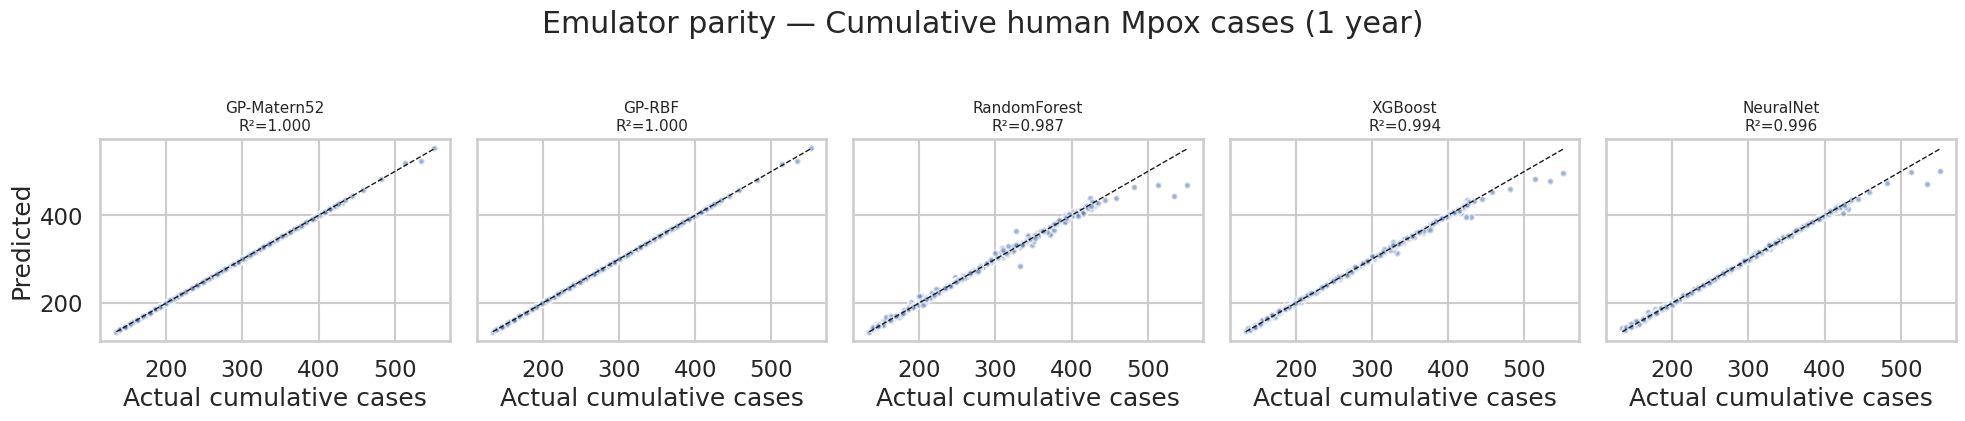


BEST EMULATOR: GP-RBF  (normalised RMSE = 0.0065)


In [23]:
# 4.6 Parity plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharey=True)
for ax, (name, ypred) in zip(axes, predictions.items()):
    ax.scatter(Y_test[:, 0], ypred[:, 0], alpha=0.55, s=20, edgecolor="white")
    lims = [Y_test[:, 0].min(), Y_test[:, 0].max()]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}\nR\u00b2={results_df.loc[name,'R2_CumCases']:.3f}", fontsize=11)
    ax.set_xlabel("Actual cumulative cases")
axes[0].set_ylabel("Predicted")
plt.suptitle("Emulator parity — Cumulative human Mpox cases (1 year)", y=1.02)
plt.tight_layout(); plt.show()

best_name = results_df["RMSE_norm"].idxmin()
print(f"\nBEST EMULATOR: {best_name}  "
      f"(normalised RMSE = {results_df.loc[best_name, 'RMSE_norm']:.4f})")
best_emulator = emulators[best_name]
gp_emulator   = emulators["GP-Matern52"]   # always GP for UQ

---
## 5. Time-Series Forecast — Real OWID Data

Independently of the simulation pipeline, we train an ML model that **forecasts the next week's Nigeria case count** from a window of recent observations. This serves two purposes:

1. **Operational early-warning**: a deployed system would use this to alert public-health authorities.
2. **Triangulation**: comparing the data-driven forecast with the white-box prediction gives a second sanity check on the calibrated model.

We use a **lag-feature gradient-boosted model** — the standard baseline that Makridakis et al. (M-competitions) found beats most deep learning models on small-data forecasting.

In [24]:
# 5.1 Build supervised lag-feature dataset on the full Nigeria series
ng_full = ng_w.copy()
ng_full["new_cases_smooth"] = ng_full["new_cases"].rolling(3, min_periods=1).mean()
LAGS = [1, 2, 3, 4, 8, 12]
for L in LAGS:
    ng_full[f"lag_{L}"] = ng_full["new_cases_smooth"].shift(L)
ng_full["roll_mean_4"] = ng_full["new_cases_smooth"].shift(1).rolling(4).mean()
ng_full["roll_std_4"]  = ng_full["new_cases_smooth"].shift(1).rolling(4).std()
ng_full["month"]       = ng_full["week"].dt.month
ng_full["weekofyear"]  = ng_full["week"].dt.isocalendar().week.astype(int)
ng_full = ng_full.dropna().reset_index(drop=True)

feature_cols = [f"lag_{L}" for L in LAGS] + ["roll_mean_4", "roll_std_4", "month", "weekofyear"]
target_col   = "new_cases_smooth"
print(f"Supervised dataset: {ng_full.shape}, {len(feature_cols)} features")

Supervised dataset: (191, 18), 10 features


In [25]:
# 5.2 Time-aware train/test split (last 20% of weeks held out)
split_idx = int(len(ng_full) * 0.80)
Xf_tr = ng_full.loc[:split_idx-1, feature_cols].values
yf_tr = ng_full.loc[:split_idx-1, target_col].values
Xf_te = ng_full.loc[split_idx:, feature_cols].values
yf_te = ng_full.loc[split_idx:, target_col].values
weeks_te = ng_full.loc[split_idx:, "week"].values
print(f"Train weeks: {len(Xf_tr)}  Test weeks: {len(Xf_te)}")

forecaster = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                              subsample=0.85, random_state=SEED, n_jobs=-1)
forecaster.fit(Xf_tr, yf_tr)
yf_pred = forecaster.predict(Xf_te)

rmse_f = float(np.sqrt(mean_squared_error(yf_te, yf_pred)))
mae_f  = float(mean_absolute_error(yf_te, yf_pred))
r2_f   = float(r2_score(yf_te, yf_pred))
print(f"Forecast RMSE: {rmse_f:.2f}  MAE: {mae_f:.2f}  R\u00b2: {r2_f:.3f}")

Train weeks: 152  Test weeks: 39
Forecast RMSE: 2.54  MAE: 1.89  R²: 0.691


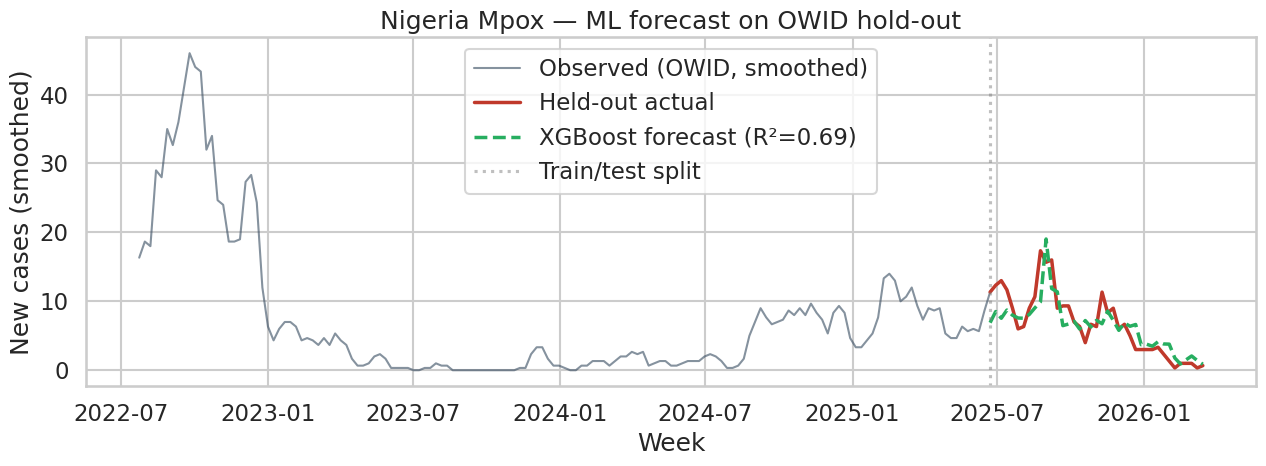

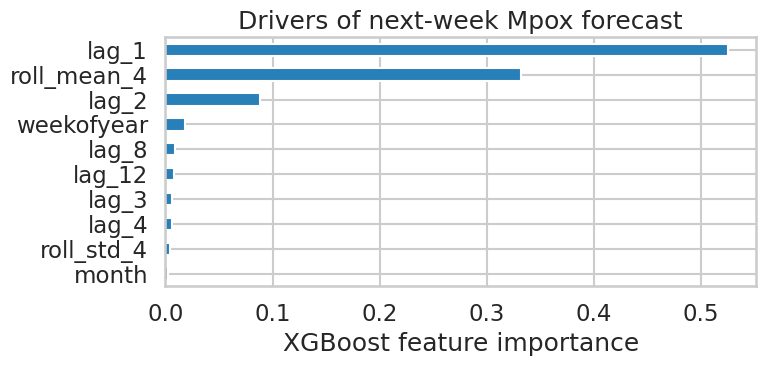

In [26]:
# 5.3 Visualise forecast and feature importance
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ng_full["week"], ng_full["new_cases_smooth"], color="#34495e", alpha=0.6,
        lw=1.5, label="Observed (OWID, smoothed)")
ax.plot(weeks_te, yf_te, color="#c0392b", lw=2.5, label="Held-out actual")
ax.plot(weeks_te, yf_pred, color="#27ae60", lw=2.5, ls="--",
        label=f"XGBoost forecast (R\u00b2={r2_f:.2f})")
ax.axvline(weeks_te[0], color="grey", ls=":", alpha=0.5, label="Train/test split")
ax.set_xlabel("Week"); ax.set_ylabel("New cases (smoothed)")
ax.set_title("Nigeria Mpox — ML forecast on OWID hold-out")
ax.legend()
plt.tight_layout(); plt.show()

imp = pd.Series(forecaster.feature_importances_, index=feature_cols).sort_values()
fig2, ax2 = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax2, color="#2980b9")
ax2.set_xlabel("XGBoost feature importance")
ax2.set_title("Drivers of next-week Mpox forecast")
plt.tight_layout(); plt.show()

---
## 6. Sobol' Sensitivity — Which One Health Lever Matters Most?

Variance-based **total-effect indices** ($S_T$) using the cheap emulator. Tells us which single intervention to prioritise if forced to pick.

In [27]:
# 6.1 Sobol' analysis (uses ~6000 emulator calls — fast)
problem = {"num_vars": 5, "names": LEVER_NAMES, "bounds": LEVER_BOUNDS.tolist()}
param_values = saltelli.sample(problem, 512, calc_second_order=False)
param_scaled = x_scaler.transform(param_values)
Y_emu = best_emulator.predict(param_scaled)
if Y_emu.ndim == 1: Y_emu = Y_emu.reshape(-1, 1)
Y_emu = y_scaler.inverse_transform(Y_emu)

Si_cases = sobol.analyze(problem, Y_emu[:, 0], calc_second_order=False, print_to_console=False)
Si_peak  = sobol.analyze(problem, Y_emu[:, 1], calc_second_order=False, print_to_console=False)

sens_df = pd.DataFrame({
    "Lever": LEVER_NAMES,
    "S1_CumCases": Si_cases["S1"], "ST_CumCases": Si_cases["ST"],
    "S1_PeakInf":  Si_peak["S1"],  "ST_PeakInf":  Si_peak["ST"],
})
print(sens_df.round(3))

   Lever  S1_CumCases  ST_CumCases  S1_PeakInf  ST_PeakInf
0     nu       -0.003        0.002       0.001       0.002
1  eta_H        0.010        0.021       0.763       0.999
2  eta_E        0.009        0.008       0.000       0.000
3  eta_A        0.000        0.000      -0.000       0.000
4  alpha        0.974        0.972       0.075       0.179


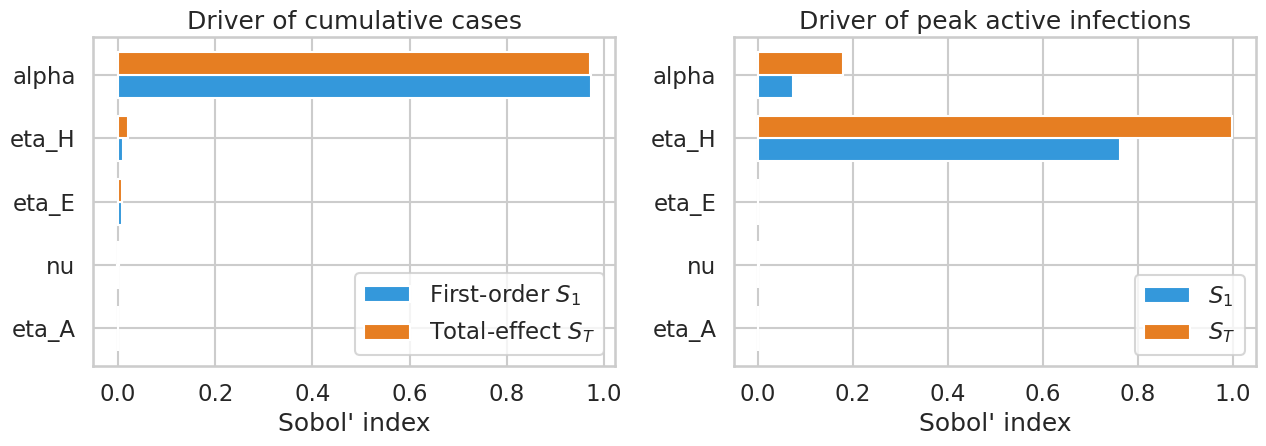

In [28]:
# 6.2 Plot Sobol' indices
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
order = sens_df.sort_values("ST_CumCases", ascending=True)["Lever"].tolist()
xpos  = np.arange(len(order))
sd = sens_df.set_index("Lever")

axes[0].barh(xpos - 0.18, [sd.loc[L,"S1_CumCases"] for L in order], 0.36,
             label="First-order $S_1$", color="#3498db")
axes[0].barh(xpos + 0.18, [sd.loc[L,"ST_CumCases"] for L in order], 0.36,
             label="Total-effect $S_T$", color="#e67e22")
axes[0].set_yticks(xpos); axes[0].set_yticklabels(order)
axes[0].set_xlabel("Sobol' index"); axes[0].set_title("Driver of cumulative cases")
axes[0].legend()

axes[1].barh(xpos - 0.18, [sd.loc[L,"S1_PeakInf"] for L in order], 0.36,
             label="$S_1$", color="#3498db")
axes[1].barh(xpos + 0.18, [sd.loc[L,"ST_PeakInf"] for L in order], 0.36,
             label="$S_T$", color="#e67e22")
axes[1].set_yticks(xpos); axes[1].set_yticklabels(order)
axes[1].set_xlabel("Sobol' index"); axes[1].set_title("Driver of peak active infections")
axes[1].legend()
plt.tight_layout(); plt.show()

---
## 7. Grey Box — Multi-Objective One Health Optimisation

The principal novelty. Three competing objectives:

1. $f_1$ = **Cumulative cases** (epidemiological burden — minimise)
2. $f_2$ = **Programme cost** (health-system burden — minimise)
3. $f_3$ = **Domain imbalance** (over-reliance on a single One Health domain — minimise)

We use **NSGA-II** (Deb et al. 2002) to find the Pareto front of non-dominated trade-offs.

In [29]:
# 7.1 Cost model + domain-imbalance penalty
COST_PER_UNIT = {
    "nu":    25_000_000,   # mass vaccination — most expensive
    "eta_H":  5_000_000,   # active surveillance / isolation
    "eta_E":  3_500_000,   # bushmeat regulation / PPE / sanitation
    "eta_A":  6_500_000,   # reservoir control
    "alpha":  1_500_000,   # awareness / risk communication
}
DOMAIN = {"nu": "human", "eta_H": "human", "eta_E": "environment",
          "eta_A": "animal", "alpha": "human"}

def total_cost(x):
    return float(sum(COST_PER_UNIT[k]*v for k, v in zip(LEVER_NAMES, x)))

def domain_imbalance(x):
    norm = (np.array(x) - LEVER_BOUNDS[:, 0]) / (LEVER_BOUNDS[:, 1] - LEVER_BOUNDS[:, 0] + 1e-12)
    by_dom = {"human": 0.0, "animal": 0.0, "environment": 0.0}
    counts = {"human": 0, "animal": 0, "environment": 0}
    for k, v in zip(LEVER_NAMES, norm):
        by_dom[DOMAIN[k]] += v
        counts[DOMAIN[k]] += 1
    avg = np.array([by_dom[d]/max(counts[d],1) for d in ["human","animal","environment"]])
    if avg.mean() < 1e-3: return 1.0
    return float(avg.std()/(avg.mean()+1e-9))

In [30]:
# 7.2 NSGA-II run
class MpoxOneHealthProblem(ElementwiseProblem):
    def __init__(self, emulator, x_scaler, y_scaler):
        super().__init__(n_var=5, n_obj=3, n_constr=0,
                         xl=LEVER_BOUNDS[:, 0], xu=LEVER_BOUNDS[:, 1])
        self.emulator = emulator
        self.x_scaler = x_scaler
        self.y_scaler = y_scaler
    def _evaluate(self, x, out, *args, **kwargs):
        xs = self.x_scaler.transform(x.reshape(1, -1))
        ys = self.emulator.predict(xs)
        if ys.ndim == 1: ys = ys.reshape(1, -1)
        y  = self.y_scaler.inverse_transform(ys)[0]
        out["F"] = [max(y[0], 0.0), total_cost(x), domain_imbalance(x)]

problem = MpoxOneHealthProblem(best_emulator, x_scaler, y_scaler)
algo    = NSGA2(pop_size=120, sampling=LHS())
res_mo  = pymoo_min(problem, algo, ("n_gen", 80), seed=SEED, verbose=False)
pareto_X, pareto_F = res_mo.X, res_mo.F
print(f"Pareto front: {len(pareto_X)} non-dominated solutions")

Pareto front: 120 non-dominated solutions


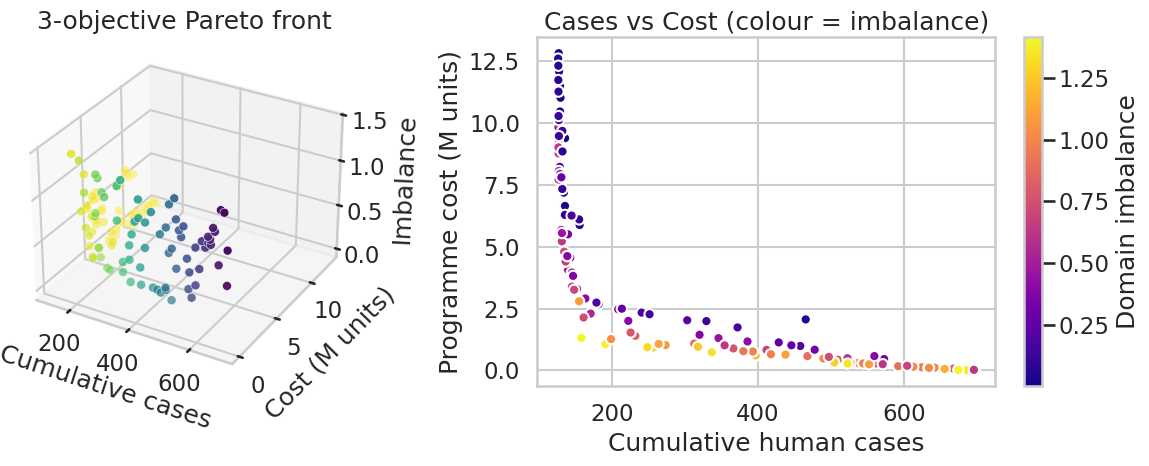

In [31]:
# 7.3 Visualise the 3-objective Pareto front
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(pareto_F[:, 0], pareto_F[:, 1]/1e6, pareto_F[:, 2],
            c=pareto_F[:, 0], cmap="viridis_r", s=42, edgecolor="white", linewidth=0.4)
ax1.set_xlabel("Cumulative cases", labelpad=8)
ax1.set_ylabel("Cost (M units)", labelpad=8)
ax1.set_zlabel("Imbalance", labelpad=8)
ax1.set_title("3-objective Pareto front")

ax2 = fig.add_subplot(122)
sc = ax2.scatter(pareto_F[:, 0], pareto_F[:, 1]/1e6,
                 c=pareto_F[:, 2], cmap="plasma", s=55, edgecolor="white")
ax2.set_xlabel("Cumulative human cases")
ax2.set_ylabel("Programme cost (M units)")
ax2.set_title("Cases vs Cost (colour = imbalance)")
plt.colorbar(sc, ax=ax2, label="Domain imbalance")
plt.tight_layout(); plt.show()

In [32]:
# 7.4 Pick three policy-relevant compromise solutions
def normalise(F):
    return (F - F.min(0)) / (F.max(0) - F.min(0) + 1e-12)

Fn = normalise(pareto_F)
idx_A = int(np.argmin(pareto_F[:, 0]))                   # burden-minimiser
idx_B = int(np.argmin(np.linalg.norm(Fn, axis=1)))       # knee point
idx_C = int(np.argmin(Fn @ np.array([0.5, 0.0, 0.5])))   # One Health champion

selections = pd.DataFrame({
    "Strategy": ["A: Burden-min", "B: Knee (balanced)", "C: One Health champion"],
    **{ln: [pareto_X[i, j] for i in [idx_A, idx_B, idx_C]]
       for j, ln in enumerate(LEVER_NAMES)},
    "CumCases":  [pareto_F[i, 0] for i in [idx_A, idx_B, idx_C]],
    "Cost(M)":   [pareto_F[i, 1]/1e6 for i in [idx_A, idx_B, idx_C]],
    "Imbalance": [pareto_F[i, 2] for i in [idx_A, idx_B, idx_C]],
})
print(selections.round(4).to_string(index=False))

              Strategy     nu  eta_H  eta_E  eta_A  alpha  CumCases  Cost(M)  Imbalance
         A: Burden-min 0.0035 0.9508 0.9983 0.4961 0.7000  126.8992  12.6096     0.0554
    B: Knee (balanced) 0.0001 0.0166 0.2705 0.1010 0.6579  182.1700   2.6760     0.1920
C: One Health champion 0.0046 0.9991 0.9792 0.4985 0.7000  127.6933  12.8284     0.0098


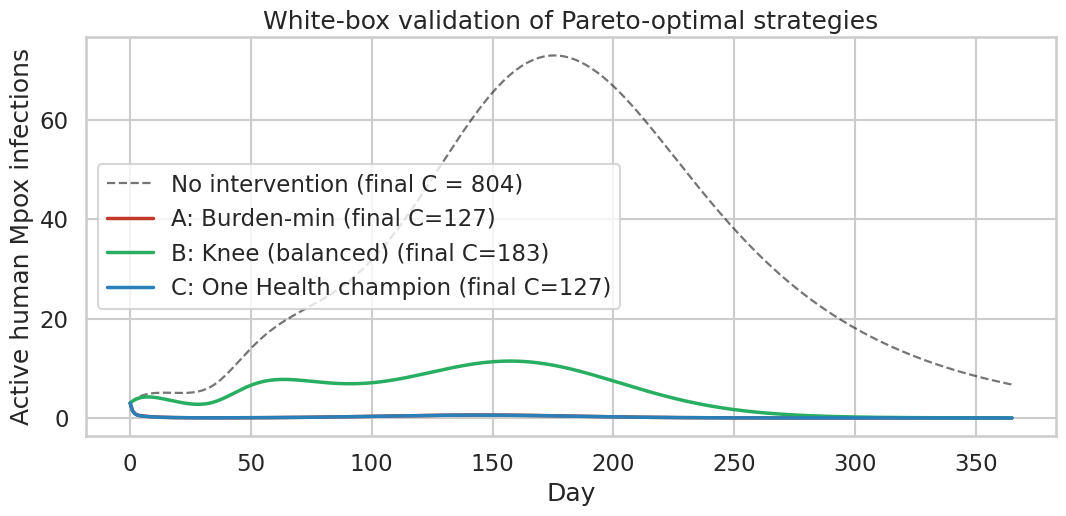

In [33]:
# 7.5 Re-simulate the three picks with the FULL calibrated white-box (validation)
fig, ax = plt.subplots(figsize=(11, 5.5))
baseline = simulate(NO_INT, params=PARAMS_CAL, ic=IC_CAL, t_max=365, importation=True)
ax.plot(baseline["t"], baseline["I_h"], "k--", lw=1.6, alpha=0.6,
        label=f"No intervention (final C = {baseline['C'].iloc[-1]:.0f})")

colors = {"A: Burden-min": "#c0392b", "B: Knee (balanced)": "#27ae60",
          "C: One Health champion": "#2980b9"}
for _, row in selections.iterrows():
    name = row["Strategy"]
    ctrl = {k: row[k] for k in LEVER_NAMES}
    sim  = simulate(ctrl, params=PARAMS_CAL, ic=IC_CAL, t_max=365, importation=True)
    ax.plot(sim["t"], sim["I_h"], lw=2.5, color=colors[name],
            label=f"{name} (final C={sim['C'].iloc[-1]:.0f})")
ax.set_xlabel("Day"); ax.set_ylabel("Active human Mpox infections")
ax.set_title("White-box validation of Pareto-optimal strategies")
ax.legend(); plt.tight_layout(); plt.show()

---
## 8. Uncertainty Quantification & Robust Recommendation

The GP gives a posterior variance for free. We propagate it to recommend a **robust** One Health package — minimising mean burden + 1 standard deviation.

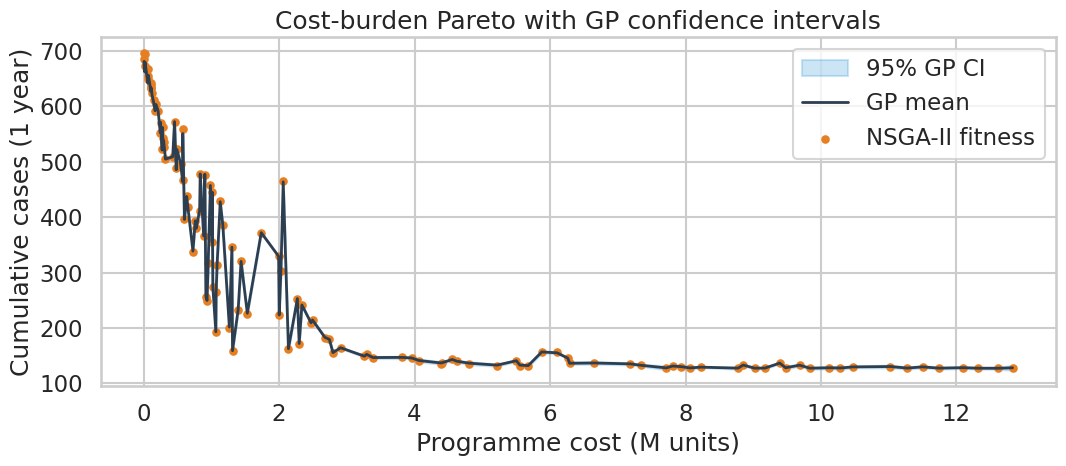

In [35]:
# 8.1 GP confidence on the Pareto solutions
gp = gp_emulator
Xs_pareto = x_scaler.transform(pareto_X)
mu_s, sigma_s = gp.predict(Xs_pareto, return_std=True)
mu = y_scaler.inverse_transform(mu_s)
sigma_cases = sigma_s * y_scaler.scale_[0] if y_scaler.scale_.size > 1 else sigma_s * y_scaler.scale_

ci_lo = mu[:, 0] - 1.96 * sigma_cases[:, 0]
ci_hi = mu[:, 0] + 1.96 * sigma_cases[:, 0]
order = np.argsort(pareto_F[:, 1])

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(pareto_F[order, 1]/1e6, ci_lo[order], ci_hi[order],
                color="#3498db", alpha=0.25, label="95% GP CI")
ax.plot(pareto_F[order, 1]/1e6, mu[order, 0], color="#2c3e50", lw=2, label="GP mean")
ax.scatter(pareto_F[order, 1]/1e6, pareto_F[order, 0], s=22,
           color="#e67e22", label="NSGA-II fitness")
ax.set_xlabel("Programme cost (M units)")
ax.set_ylabel("Cumulative cases (1 year)")
ax.set_title("Cost-burden Pareto with GP confidence intervals")
ax.legend(); plt.tight_layout(); plt.show()

In [37]:
robust_score = mu[:, 0] + sigma_cases[:, 0]
idx_robust = int(np.argmin(robust_score))
print("=== ROBUST One Health recommendation ===")
for k, v in zip(LEVER_NAMES, pareto_X[idx_robust]):
    print(f"  {k:6s} = {v:.4f}")
print(f"  Predicted cumulative cases: {mu[idx_robust, 0]:.0f} \u00b1 {1.96*sigma_cases[idx_robust, 0]:.0f} (95% CI)")
print(f"  Cost: {pareto_F[idx_robust,1]/1e6:.2f} M units")
print(f"  Domain imbalance: {pareto_F[idx_robust,2]:.3f}")

=== ROBUST One Health recommendation ===
  nu     = 0.0035
  eta_H  = 0.8330
  eta_E  = 0.9974
  eta_A  = 0.0348
  alpha  = 0.6996
  Predicted cumulative cases: 127 ± 1 (95% CI)
  Cost: 9.02 M units
  Domain imbalance: 0.638


=== Posterior-propagated burden under robust recommendation ===
  Posterior mean:   126
  Posterior median: 127
  95% credible:     [78, 166]
  90% credible:     [87, 159]


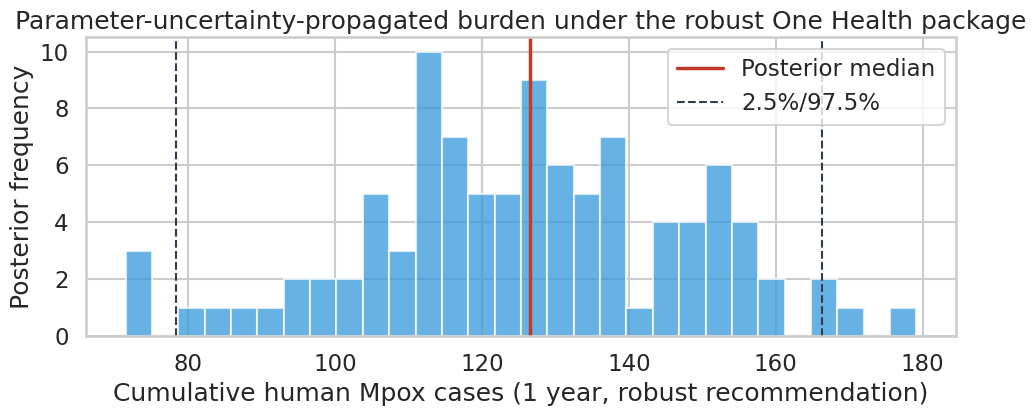


This is the FINAL uncertainty quantification: the credible interval above
includes both calibration uncertainty (from MCMC) and dynamic uncertainty
(from the ODE non-linearity). It is what a policymaker should be shown.


In [38]:
# 8.3 Propagate posterior parameter uncertainty to the Pareto front
# For each posterior draw we recompute the cumulative cases under the robust
# recommendation. This is the *full* uncertainty: emulator UQ (Section 8.1)
# captures the surface; this captures the calibration uncertainty.
N_DRAWS = 100   # 100 ODE solves x ~ 1s each = ~100s on Colab
draw_idx = np.random.RandomState(SEED).choice(len(samples), N_DRAWS, replace=False)

robust_lever = pareto_X[idx_robust]
robust_ctrl  = dict(zip(LEVER_NAMES, robust_lever))

burdens = []
for i in draw_idx:
    p_draw = dict(PARAMS_CAL)
    p_draw["beta_hh"] = samples[i, 0]
    p_draw["beta_rh"] = samples[i, 1]
    p_draw["ext_amp"] = samples[i, 4]
    p_draw["t_peak"]  = samples[i, 5]
    p_draw["t_width"] = samples[i, 6]
    Nh, Nr = samples[i, 2], samples[i, 3]
    p_draw["Lambda_h"] = Nh * p_draw["mu_h"]
    p_draw["Lambda_r"] = Nr * p_draw["mu_r"]
    ic_draw = {"S_h": Nh-8, "V_h": 0.0, "E_h": 5.0, "I_h": 3.0, "Q_h": 0.0,
               "R_h": 0.0, "S_r": Nr-30, "I_r": 30.0, "R_r": 0.0, "C": 0.0}
    try:
        df = simulate(robust_ctrl, params=p_draw, ic=ic_draw, t_max=365, importation=True)
        burdens.append(float(df["C"].iloc[-1]))
    except Exception:
        continue
burdens = np.array(burdens)

print("=== Posterior-propagated burden under robust recommendation ===")
print(f"  Posterior mean:   {burdens.mean():.0f}")
print(f"  Posterior median: {np.median(burdens):.0f}")
print(f"  95% credible:     [{np.quantile(burdens, 0.025):.0f}, "
      f"{np.quantile(burdens, 0.975):.0f}]")
print(f"  90% credible:     [{np.quantile(burdens, 0.05):.0f}, "
      f"{np.quantile(burdens, 0.95):.0f}]")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(burdens, bins=30, color="#3498db", alpha=0.75, edgecolor="white")
ax.axvline(np.median(burdens), color="#c0392b", lw=2.5, label="Posterior median")
ax.axvline(np.quantile(burdens, 0.025), color="#2c3e50", lw=1.5, ls="--",
           label="2.5%/97.5%")
ax.axvline(np.quantile(burdens, 0.975), color="#2c3e50", lw=1.5, ls="--")
ax.set_xlabel("Cumulative human Mpox cases (1 year, robust recommendation)")
ax.set_ylabel("Posterior frequency")
ax.set_title("Parameter-uncertainty-propagated burden under the robust One Health package")
ax.legend()
plt.tight_layout(); plt.show()

print()
print("This is the FINAL uncertainty quantification: the credible interval above")
print("includes both calibration uncertainty (from MCMC) and dynamic uncertainty")
print("(from the ODE non-linearity). It is what a policymaker should be shown.")

---
## 9. Ablation — Does Integrated One Health Actually Help?

We re-run the optimisation with one or two domains *disabled* and compare Pareto fronts. This directly addresses the gap that few studies use all three domains.

In [39]:
# 9.1 Constrained optimisations (each takes ~10s; total ~1 min)
def run_constrained(active_domains, n_gen=60):
    class P(ElementwiseProblem):
        def __init__(self):
            super().__init__(n_var=5, n_obj=2, n_constr=0,
                             xl=LEVER_BOUNDS[:, 0], xu=LEVER_BOUNDS[:, 1])
        def _evaluate(self, x, out, *a, **kw):
            x_eff = np.array([x[i] if DOMAIN[LEVER_NAMES[i]] in active_domains else 0.0
                              for i in range(5)])
            xs = x_scaler.transform(x_eff.reshape(1, -1))
            ys = best_emulator.predict(xs)
            if ys.ndim == 1: ys = ys.reshape(1, -1)
            y = y_scaler.inverse_transform(ys)[0]
            out["F"] = [max(y[0], 0.0), total_cost(x_eff)]
    res = pymoo_min(P(), NSGA2(pop_size=80, sampling=LHS()),
                    ("n_gen", n_gen), seed=SEED, verbose=False)
    return res.F, res.X

scenarios = {
    "Human-only":              {"human"},
    "Animal-only":             {"animal"},
    "Environment-only":        {"environment"},
    "Human+Animal":            {"human", "animal"},
    "Human+Environment":       {"human", "environment"},
    "Full One Health (all 3)": {"human", "animal", "environment"},
}
ablation = {}
for name, dom in scenarios.items():
    F, X = run_constrained(dom)
    ablation[name] = {"F": F, "X": X}
    print(f"  {name:30s} -> {len(F)} Pareto solutions")

  Human-only                     -> 80 Pareto solutions
  Animal-only                    -> 80 Pareto solutions
  Environment-only               -> 80 Pareto solutions
  Human+Animal                   -> 80 Pareto solutions
  Human+Environment              -> 80 Pareto solutions
  Full One Health (all 3)        -> 80 Pareto solutions


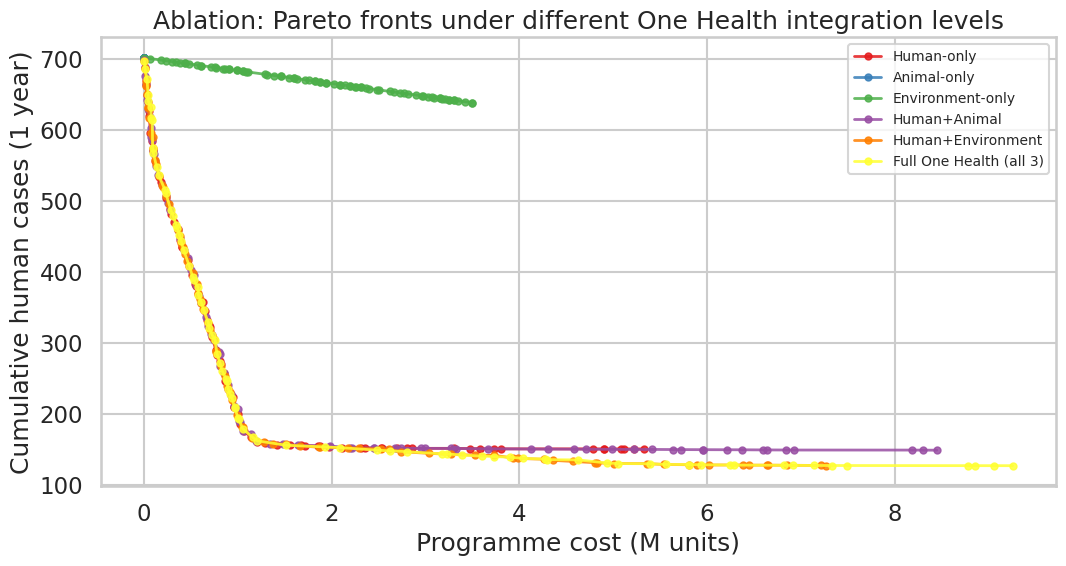


=== Fragmenting One Health costs you cases (lower is better) ===
               Scenario  Best cases at <= 10.0M
Full One Health (all 3)              127.088759
      Human+Environment              127.334047
           Human+Animal              148.903217
             Human-only              150.617814
       Environment-only              637.908940
            Animal-only              701.308890


In [40]:
# 9.2 Compare Pareto fronts
fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette("Set1", n_colors=len(scenarios))
for (name, data), color in zip(ablation.items(), palette):
    F = data["F"]
    order = np.argsort(F[:, 1])
    ax.plot(F[order, 1]/1e6, F[order, 0], "o-", color=color,
            alpha=0.85, label=name, markersize=5, linewidth=2)
ax.set_xlabel("Programme cost (M units)")
ax.set_ylabel("Cumulative human cases (1 year)")
ax.set_title("Ablation: Pareto fronts under different One Health integration levels")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout(); plt.show()

budget_M = 10.0
summary = []
for name, data in ablation.items():
    F = data["F"]
    feas = F[F[:, 1]/1e6 <= budget_M]
    summary.append({"Scenario": name,
                    f"Best cases at <= {budget_M}M": (feas[:, 0].min() if len(feas) else np.nan)})
print("\n=== Fragmenting One Health costs you cases (lower is better) ===")
print(pd.DataFrame(summary).sort_values(f"Best cases at <= {budget_M}M").to_string(index=False))

---
## 10. Synthesised Policy Dashboard

A one-page summary of what the ML-driven One Health system recommends for Mpox in Nigeria, given the calibrated dynamics.

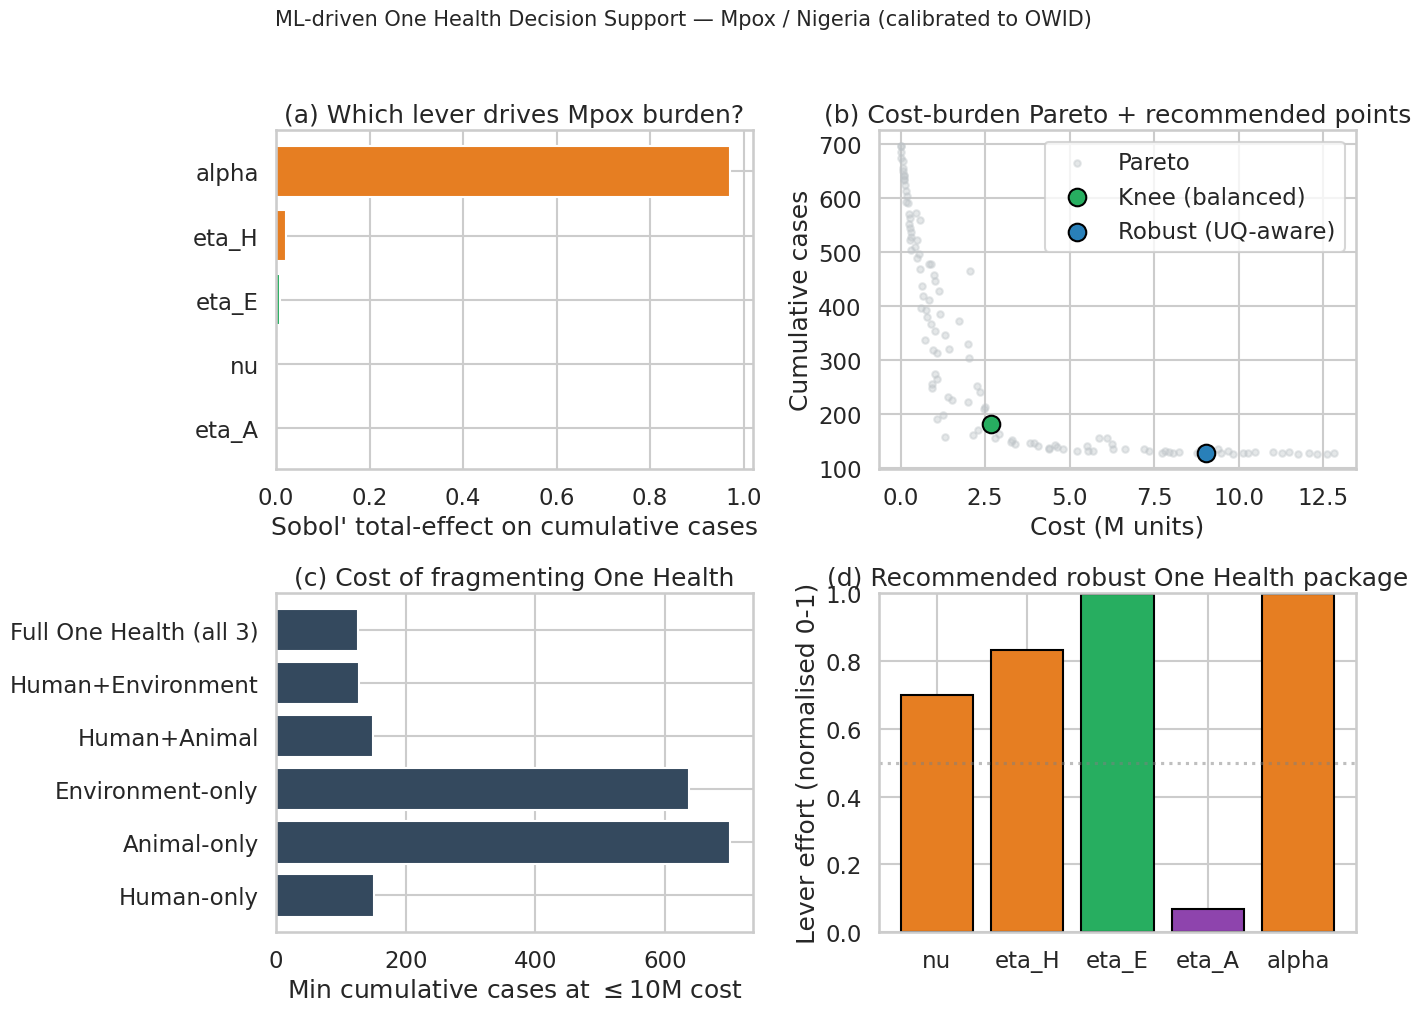

In [42]:
# 10.1 Dashboard (4-panel)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Sensitivity bars
levers_sorted = sens_df.sort_values("ST_CumCases", ascending=True)
bar_colors = ["#e67e22" if DOMAIN[L]=="human" else "#27ae60" if DOMAIN[L]=="environment"
              else "#8e44ad" for L in levers_sorted["Lever"]]
axes[0, 0].barh(levers_sorted["Lever"], levers_sorted["ST_CumCases"], color=bar_colors)
axes[0, 0].set_xlabel("Sobol' total-effect on cumulative cases")
axes[0, 0].set_title("(a) Which lever drives Mpox burden?")

# (b) Pareto + recommended points
ax = axes[0, 1]
ax.scatter(pareto_F[:, 1]/1e6, pareto_F[:, 0], alpha=0.4, c="#bdc3c7", s=22, label="Pareto")
ax.scatter(pareto_F[idx_B, 1]/1e6, pareto_F[idx_B, 0], s=160, c="#27ae60",
           edgecolor="black", label="Knee (balanced)")
ax.scatter(pareto_F[idx_robust, 1]/1e6, pareto_F[idx_robust, 0], s=160, c="#2980b9",
           edgecolor="black", label="Robust (UQ-aware)")
ax.set_xlabel("Cost (M units)"); ax.set_ylabel("Cumulative cases")
ax.set_title("(b) Cost-burden Pareto + recommended points")
ax.legend()

# (c) Ablation bar
scen_names = list(ablation.keys())
best_at_b = []
for n in scen_names:
    F = ablation[n]["F"]
    feas = F[F[:, 1]/1e6 <= 10.0]
    best_at_b.append(feas[:, 0].min() if len(feas) else np.nan)
axes[1, 0].barh(scen_names, best_at_b, color="#34495e")
axes[1, 0].set_xlabel(r"Min cumulative cases at $\leq$10M cost")
axes[1, 0].set_title("(c) Cost of fragmenting One Health")

# (d) Recommended robust mix
levers = LEVER_NAMES
values = pareto_X[idx_robust]
norm = (values - LEVER_BOUNDS[:, 0]) / (LEVER_BOUNDS[:, 1] - LEVER_BOUNDS[:, 0])
colors_d = ["#e67e22" if DOMAIN[L]=="human" else "#27ae60" if DOMAIN[L]=="environment"
            else "#8e44ad" for L in levers]
axes[1, 1].bar(levers, norm, color=colors_d, edgecolor="black")
axes[1, 1].set_ylabel("Lever effort (normalised 0-1)")
axes[1, 1].set_title("(d) Recommended robust One Health package")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].axhline(0.5, color="grey", ls=":", alpha=0.5)

plt.suptitle("ML-driven One Health Decision Support — Mpox / Nigeria (calibrated to OWID)",
             fontsize=15, y=1.02)
plt.tight_layout(); plt.show()



### Citations
- Zhao Z, Wang L, Bergquist R, et al. (2025). *Crafting an innovative one health-aligned machine learning framework for neglected tropical diseases elimination*. **Science in One Health**.
- Yinka-Ogunleye A, et al. (2019). *Outbreak of human monkeypox in Nigeria 2017-18*. **Lancet Infectious Diseases**.
- Sani Rabiu S, et al. (2025). *Modeling the transmission dynamics of Mpox virus*. **Scientific Reports**.
- Doty JB, et al. (2023). *Orthopoxvirus Infections in Rodents, Nigeria, 2018–2019*. **Emerging Infectious Diseases**.
- Madubueze CE, et al. (2022). *The transmission dynamics of the monkeypox virus in the presence of environmental transmission*. **Frontiers in Applied Mathematics and Statistics**.
- Deb K, Pratap A, Agarwal S, Meyarivan T (2002). *NSGA-II*. **IEEE Trans. Evol. Comput.**
- Rasmussen CE, Williams CKI (2006). *Gaussian Processes for Machine Learning*. MIT Press.
- Foreman-Mackey D, Hogg DW, Lang D, Goodman J (2013). *emcee: The MCMC Hammer*. **PASP** 125, 306-312.
- Our World in Data — *Mpox (monkeypox)*: https://ourworldindata.org/mpox

---

